In [ ]:
%load_ext autoreload
%autoreload 2

import sys
import os
import json
from datetime import datetime

sys.path.append(os.path.abspath('../src'))

from config.vessel_specs import POWER_CONFIG, DELAY_PARAMS
from orchestrator import KiaraOrchestrator
from utils.viz import plot_micro_power_trace

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
with open('../src/config/schedule.json', 'r') as f:
    cyclades_schedule = json.load(f)

with open('../src/config/weather_params.json', 'r') as f:
    climate_db = json.load(f)

In [5]:
TARGET_MONTH = "8" 
month_data = climate_db[TARGET_MONTH]

start_time = datetime(2026, int(TARGET_MONTH), 3, 7, 0)

orchestrator = KiaraOrchestrator(
    schedule=cyclades_schedule,
    start_dt=start_time,
    delay_params=DELAY_PARAMS,
    power_config=POWER_CONFIG,
    weather_params=month_data["jacobi"],
    k_factors=month_data["k_factors"]
)

In [10]:
df_macro, df_micro = orchestrator.run_simulation(days=1)

--- Starting KIARA Simulation (1 Days) ---
1. Generating Macro Dispatcher Timeline...
2. Generating Meso Weather (Jacobi SDE)...
3. Generating Micro Bivariate Power Traces...
Expanding macro timeline to high-frequency micro traces...
Simulation Complete!


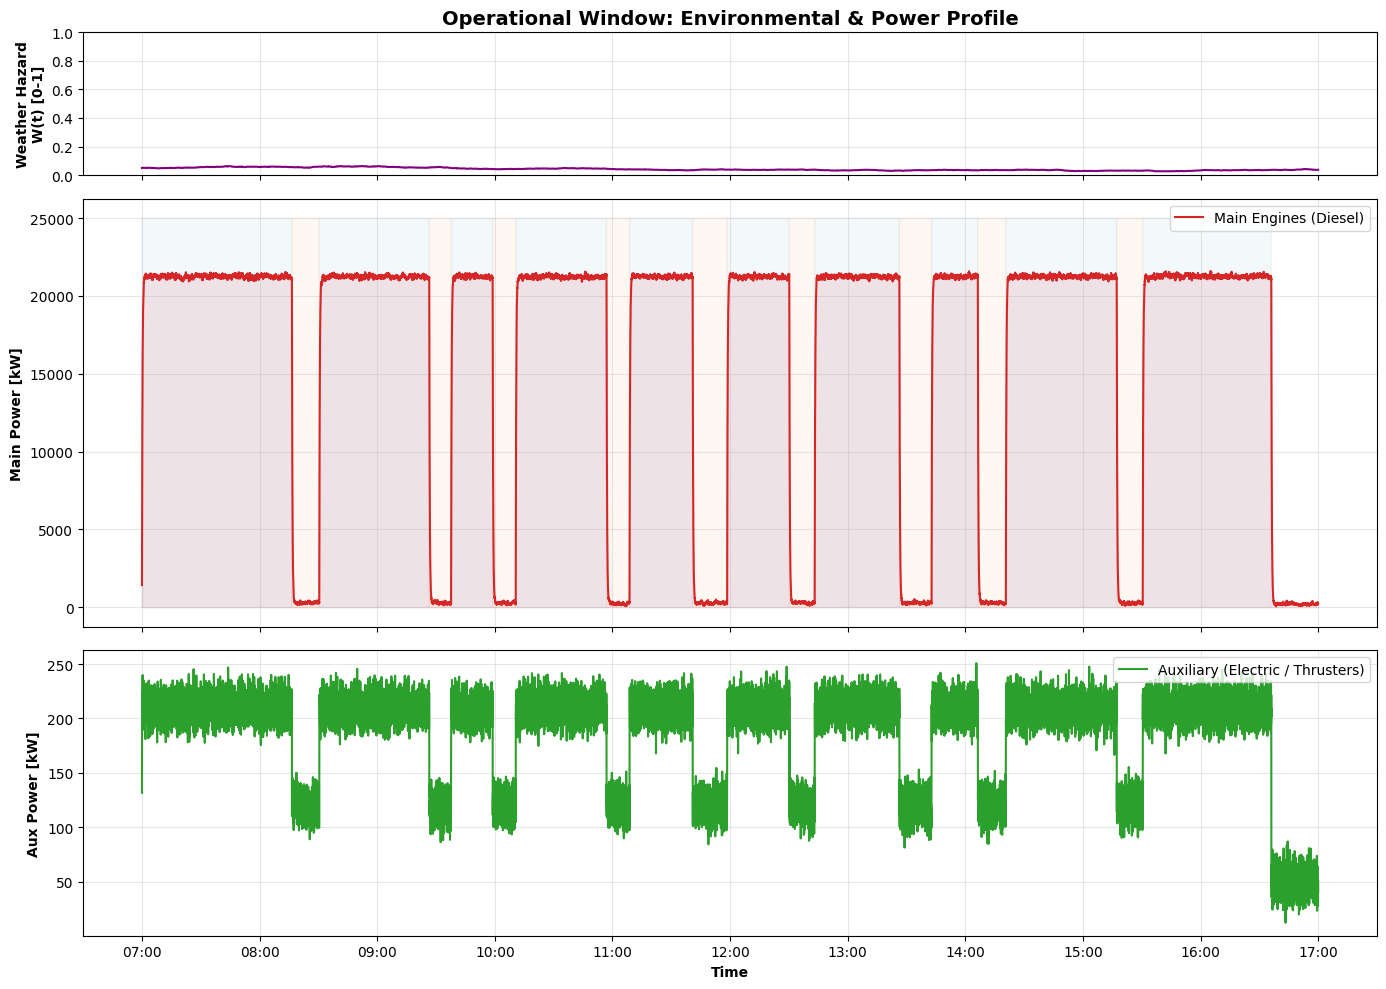

In [11]:
plot_micro_power_trace(df_micro, window_minutes=600, start_idx=0)